Samara Wardasadiya (F1D02410023)

In [21]:
import numpy as np  
import matplotlib.pyplot as plt
import cv2 as cv

from pcdlib import manimg as img
from pcdlib import manhist as lib

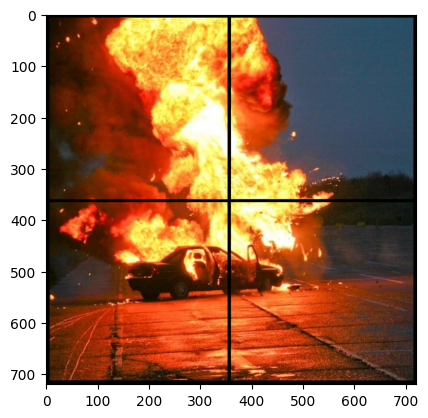

In [22]:
baca = cv.imread('Assets/Meledak.png')
boom = cv.cvtColor(baca, cv.COLOR_BGR2RGB)
plt.imshow(boom, cmap="gray")

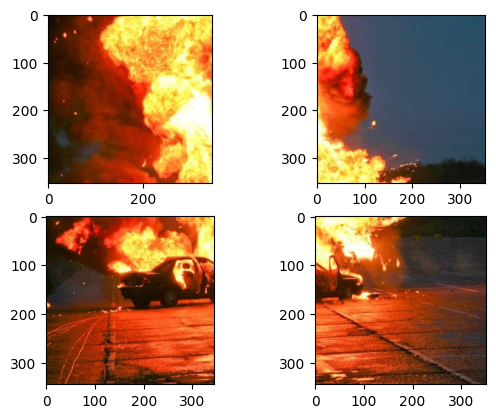

In [23]:
# slice
h, w, d = boom.shape
boom1 = boom[7:359, 7:352]
boom2 = boom[7:359, 363:715]
boom3 = boom[368:713, 7:352]
boom4 = boom[368:713, 363:715]

plt.subplot(2,2,1)
plt.imshow(boom1, cmap="gray")
plt.subplot(2,2,2)
plt.imshow(boom2, cmap="gray")
plt.subplot(2,2,3)
plt.imshow(boom3, cmap="gray")
plt.subplot(2,2,4)
plt.imshow(boom4, cmap="gray")

In [24]:
print(boom1.shape)
print(boom2.shape)
print(boom3.shape)
print(boom4.shape)

(352, 345, 3)
(352, 352, 3)
(345, 345, 3)
(345, 352, 3)


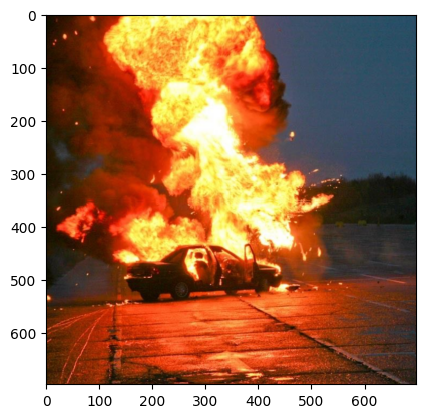

In [25]:
# gabung
atas = img.merge_image(boom1, boom2, 'H')
bawah = img.merge_image(boom3, boom4, 'H')

jadi = img.merge_image(atas, bawah, 'V')
# plt.imshow(atas, cmap="gray")
# plt.imshow(bawah, cmap="gray")
plt.imshow(jadi, cmap="gray")

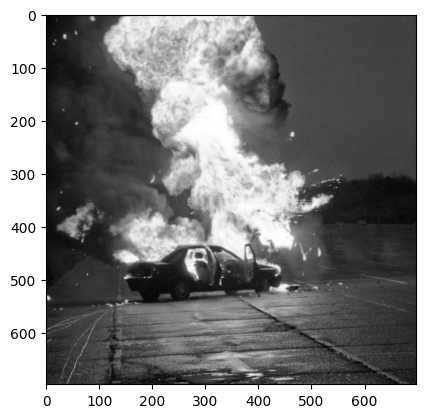

In [26]:
#  citra diubah menjadi grayscale
# boom_gray = img.to_grayscale(jadi)
boom_gray = cv.cvtColor(jadi, cv.COLOR_RGB2GRAY)
plt.imshow(boom_gray, cmap="gray")

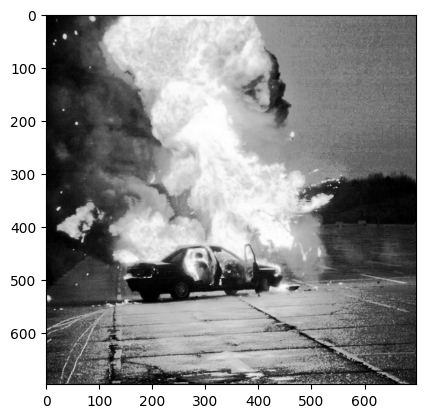

In [27]:
# proses equalization
boom_equal = lib.equalization_grayscale(boom_gray)
plt.imshow(boom_equal, cmap="gray")


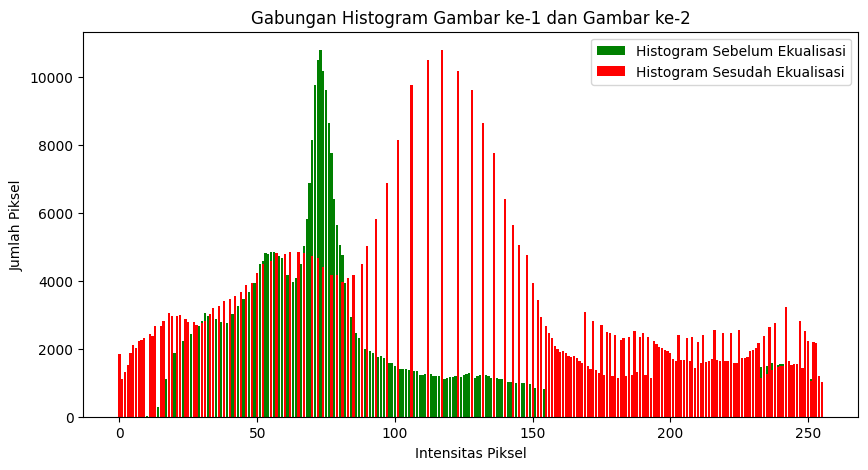

In [28]:
# tampilin histogram gabungan

histo1 = img.buat_hist(boom_gray)
histo2 = img.buat_hist(boom_equal)

lib.plot_histo_double("Gabungan Histogram Gambar ke-1 dan Gambar ke-2", histo1, "Histogram Sebelum Ekualisasi", "green", histo2, "Histogram Sesudah Ekualisasi", "red")

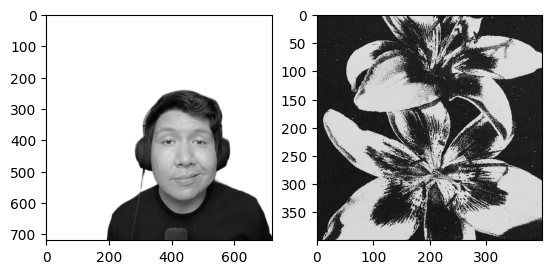

In [29]:
# Baca windut dan bunga
ambil = cv.imread('Assets/Windut.png')
windut = cv.cvtColor(ambil, cv.COLOR_BGR2GRAY)

take = cv.imread('Assets/Bunga.png')
bunga = cv.cvtColor(take, cv.COLOR_BGR2GRAY)


plt.subplot(1, 2, 1)
plt.imshow(windut, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(bunga, cmap="gray")


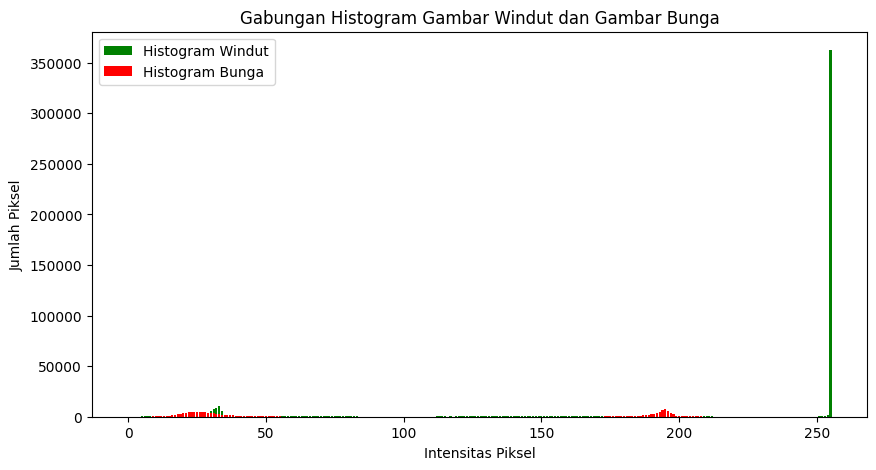

In [30]:
# ampilkan histogram citra Windut dan citra bunga ireng.
histo_windut = img.buat_hist(windut)
histo_bunga = img.buat_hist(bunga)

lib.plot_histo_double("Gabungan Histogram Gambar Windut dan Gambar Bunga", histo_windut, "Histogram Windut", "green", histo_bunga, "Histogram Bunga", "red")

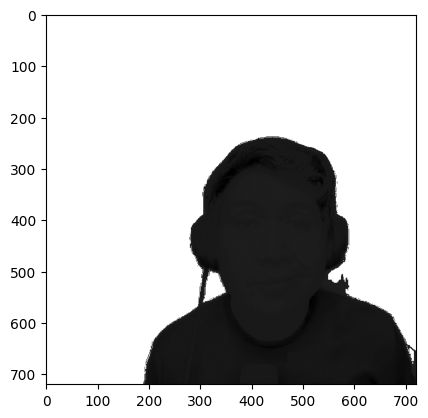

In [31]:
# spesifikasi  pada  citra  Windut  dengan  citra  bunga  ireng
windut_spesi = lib.specification_gray_to_gray(windut, bunga)
plt.imshow(windut_spesi, cmap="gray")

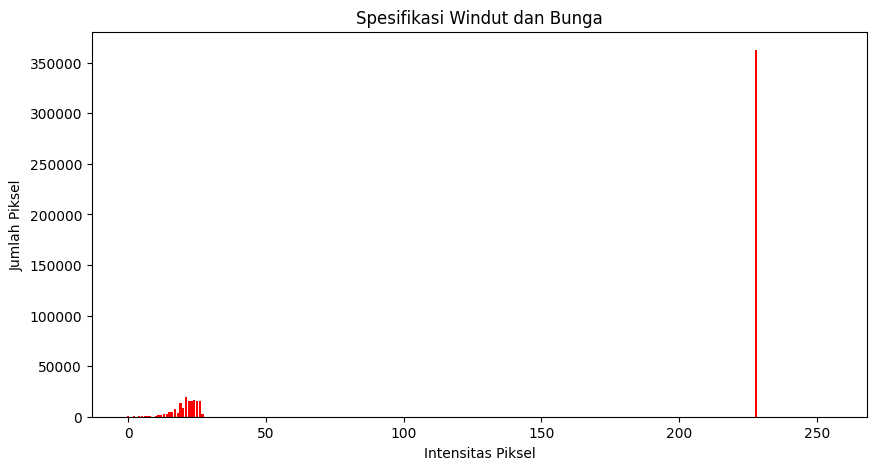

In [32]:
# histogram spesifikasi citra  Windut  dengan  citra  bunga  ireng
histo_Windut_spesi = img.buat_hist(windut_spesi)

lib.plot_histogram(histo_Windut_spesi, "Spesifikasi Windut dan Bunga", "red")

In [33]:
print(boom_equal.shape)
print(windut_spesi.shape)

(697, 697)
(720, 720)


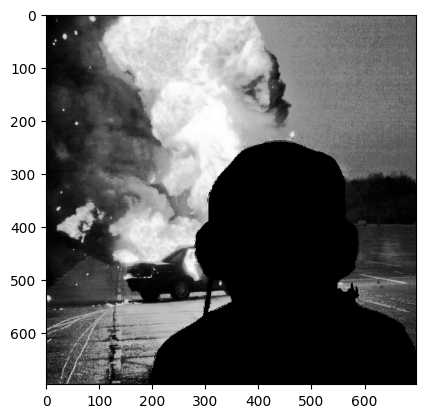

In [34]:
# cropping agar dimensinya sama
windut_resize = windut_spesi[0:697, 0:697]
windut_mask = img.threshold(windut_resize)

# proses masking
masking = lib.masking_gray_to_gray(boom_equal, windut_mask)
plt.imshow(masking, cmap="gray")


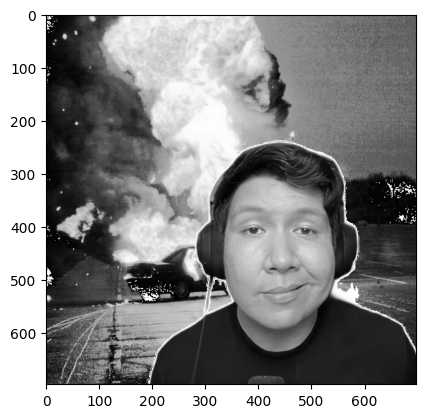

In [35]:
# penggabungan citra denganmenempelkan objek utama kebackground
akhir = masking + windut[0:697, 0:697]

plt.imshow(akhir, cmap="gray")

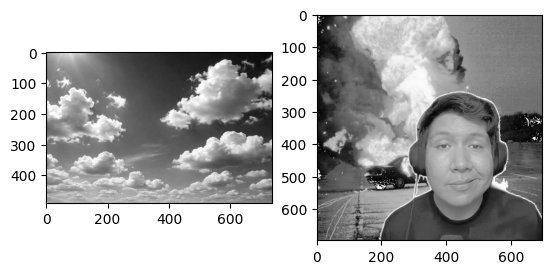

In [36]:
# spesifikasi akhir
taulah = cv.imread('Assets/Langit.png')
langit = cv.cvtColor(taulah, cv.COLOR_BGR2GRAY)

spe_akhir = lib.specification_gray_to_gray(akhir, langit)

plt.subplot(1, 2, 1)
plt.imshow(langit, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(spe_akhir, cmap="gray")


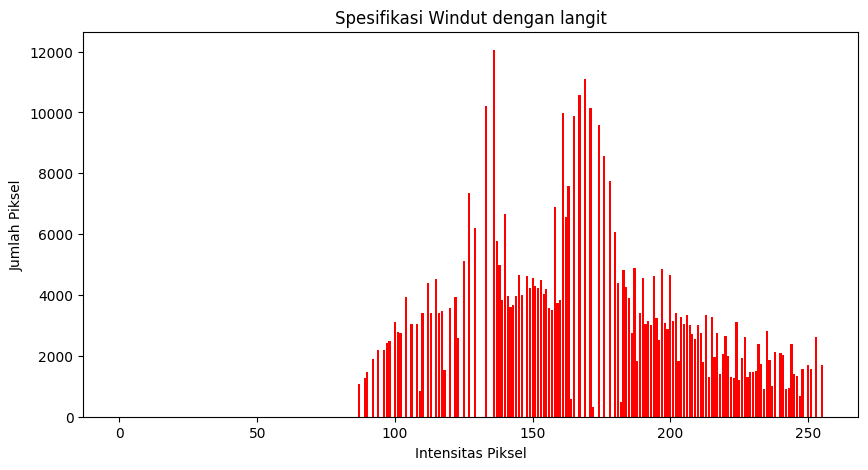

In [37]:
# Histogram spesifikasi akhir

histo_spe_akhir = img.buat_hist(spe_akhir)
lib.plot_histogram(histo_spe_akhir, "Spesifikasi Windut dengan langit", "red")

(490, 735, 3)
(697, 697, 3)


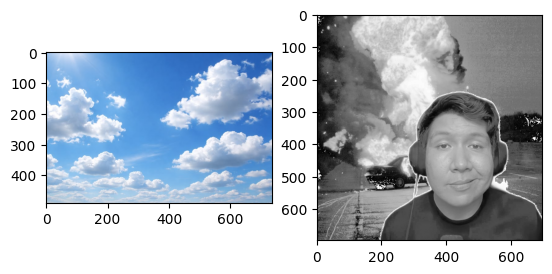

In [39]:
lagi = cv.imread('Assets/Langit.png')
langit_cerah = cv.cvtColor(taulah, cv.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(langit_cerah, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(spe_akhir, cmap="gray")

print(langit_cerah.shape)
print(jadi.shape)


(np.float64(-0.5), np.float64(696.5), np.float64(696.5), np.float64(-0.5))

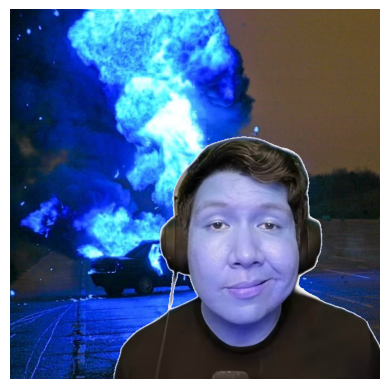

In [40]:
windut_color = cv.imread("Assets/Windut.png")

windut_mask = np.zeros_like(windut_color)
for i in range(windut_color.shape[0]):
    for j in range(windut_color.shape[1]):
        if windut[i, j] < 250:  # pakai grayscale sebagai mask
            windut_mask[i, j] = windut_color[i, j]

windut_mask = windut_mask[0:697, 0:697]
jadi = cv.cvtColor(jadi, cv.COLOR_RGB2BGR)

windut_last = np.zeros_like(windut_mask)
for i in range(windut_mask.shape[0]):
    for j in range(windut_mask.shape[1]):
        if windut_mask[i, j, 0] == 0 and windut_mask[i, j, 1] == 0 and windut_mask[i, j, 2] == 0:
            windut_last[i, j] = jadi[i, j]
        else:
            windut_last[i, j] = windut_mask[i, j]

plt.imshow(windut_last)
plt.axis('off')
